In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mako.util import to_list
from pandas.core.common import random_state

df=pd.read_csv('../data/raw_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [56]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,PaperlessBilling,MonthlyCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,1,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,1,0,56.95,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,1,53.85,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,1,0,42.30,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,0,1,70.70,...,False,False,False,False,False,False,False,False,True,False


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# BINARY ENCODING

IT IS SIMPLE , IT WILL BE HAVING 2 OPTIONS ONLY SO WE TURN IT INTO 0 AND 1
-features with 2,3,4 options we do hot encoding

In [6]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [88]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [60]:
df.shape

(7043, 21)

In [94]:
binary_cols=['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']


df[binary_cols]=df[binary_cols].replace({
    'Yes':1,'No':0,
'Male':1,'Female':0}
)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


# one hot encoding

In [95]:
multi_cat_columns=[ 'MultipleLines', 'InternetService', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod','OnlineSecurity']



In [96]:
df=pd.get_dummies(df,columns=multi_cat_columns,drop_first=True)

In [66]:
df.shape

(7043, 31)

In [98]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [99]:
df=df.drop('customerID',axis=1)

In [100]:
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)

In [103]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes'],
      dtype='object')

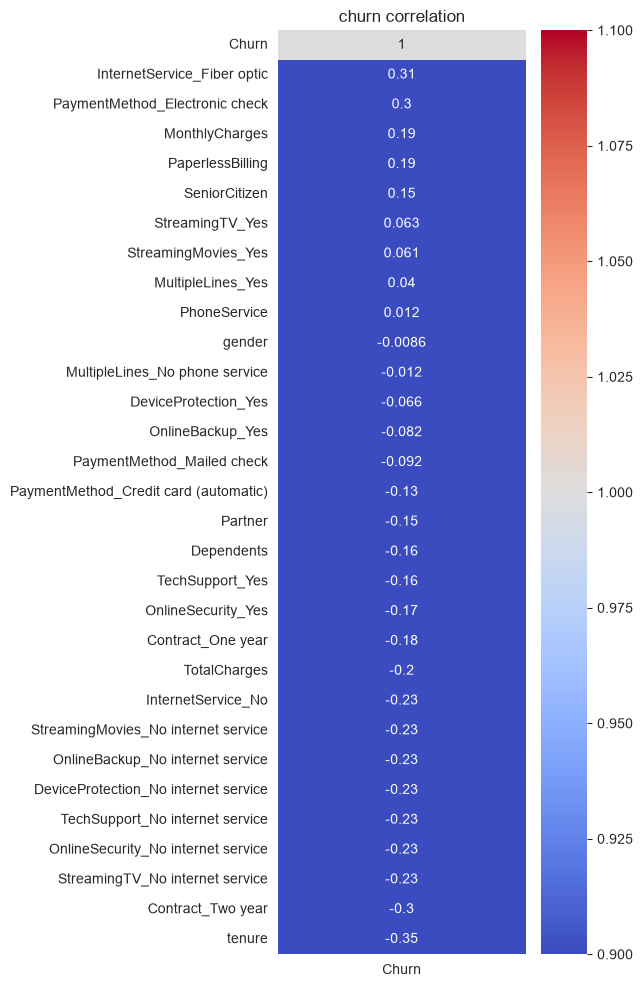

In [104]:
corr_matrix=df.corr(numeric_only=True)

churn_corr=corr_matrix[['Churn']].sort_values(ascending=False,by='Churn')

plt.figure(figsize=(4,12))
sns.heatmap(churn_corr,annot=True,cmap='coolwarm',vmin=1,vmax=1)

plt.title('churn correlation')
plt.show()

In [105]:
df['Churn'].value_counts()
#class imbalance

Churn
0    5174
1    1869
Name: count, dtype: int64

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve
import time


x=df.drop(columns=['Churn'])
y=df['Churn']


x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20,stratify=y)

THRESHOLD= 0.3

#WE ARE FOCUSING ON OPTIMIZING RECALL , THAT IF WE PREDICT THAT CUSTOMER GONNA CHURN THEN IT SHOULD HAPPEN
#WHICH CAN EVENTUALLY LOWER THE PRECISION


In [108]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   MultipleLines_No phone service         7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  Inte

In [112]:
from xgboost import XGBClassifier

In [124]:
from sklearn.metrics import accuracy_score
model1 = RandomForestClassifier(random_state=42,
                                n_estimators=300,
                                class_weight='balanced',
                                n_jobs=-1
                                )

model1.fit(x_train, y_train)

proba=model1.predict_proba(x_test)[:,1]
y_pred=(proba>=THRESHOLD).astype(int)

print(proba)

print(classification_report(y_test,y_pred,digits=3))
print(accuracy_score(y_test,y_pred))

[0.00333333 0.88333333 0.13333333 ... 0.10666667 0.14666667 0.02333333]
              precision    recall  f1-score   support

           0      0.927     0.667     0.776      1035
           1      0.481     0.856     0.616       374

    accuracy                          0.717      1409
   macro avg      0.704     0.761     0.696      1409
weighted avg      0.809     0.717     0.733      1409

0.716820440028389


In [121]:
from sklearn.metrics import accuracy_score

import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)
strat_train = time.time()
model2.fit(x_train, y_train)
train_time = time.time() - strat_train
print(f'{train_time:.2f} seconds')


proba=model2.predict_proba(x_test)[:,1]
y_pred=(proba>=THRESHOLD).astype(int)

print(proba)

print(classification_report(y_test,y_pred,digits=3))
print(accuracy_score(y_test,y_pred))

2.37 seconds
[0.00596438 0.97668535 0.1773536  ... 0.11714326 0.26489517 0.00393625]
              precision    recall  f1-score   support

           0      0.910     0.684     0.781      1035
           1      0.482     0.813     0.605       374

    accuracy                          0.718      1409
   macro avg      0.696     0.748     0.693      1409
weighted avg      0.796     0.718     0.734      1409

0.7182398864442867


In [ ]:
#we choose random forest because of the recall rate is high in random forest

In [129]:
feature_importance=pd.DataFrame({
    'feature_name':x_train.columns,
    'importance':model2.feature_importances_
}).sort_values(ascending=False,by='importance')


In [130]:
feature_importance

,feature_name,importance
24,Contract_Two year,0.324005
11,InternetService_Fiber optic,0.123734
23,Contract_One year,0.092672
13,OnlineBackup_No internet service,0.079807
12,InternetService_No,0.076738
26,PaymentMethod_Electronic check,0.027607
22,StreamingMovies_Yes,0.021919
5,PhoneService,0.018598
9,MultipleLines_No phone service,0.017684
4,tenure,0.017642


In [142]:
selected_feature=feature_importance.loc[feature_importance['importance']>=0.01,'feature_name'].to_list()

In [143]:
x=df[selected_feature]
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20,stratify=y)
from sklearn.metrics import accuracy_score

import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)
strat_train = time.time()
model2.fit(x_train, y_train)
train_time = time.time() - strat_train
print(f'{train_time:.2f} seconds')

proba = model2.predict_proba(x_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(proba)

print(classification_report(y_test, y_pred, digits=3))
print(accuracy_score(y_test, y_pred))

0.69 seconds
[0.00326858 0.97378564 0.26398286 ... 0.10132358 0.21823156 0.00351508]
              precision    recall  f1-score   support

           0      0.915     0.694     0.789      1035
           1      0.492     0.821     0.615       374

    accuracy                          0.727      1409
   macro avg      0.703     0.757     0.702      1409
weighted avg      0.802     0.727     0.743      1409

0.7274662881476224


In [144]:
from sklearn.metrics import recall_score

thresh = [0.20, 0.21, 0.24, 0.26, 0.27, 0.3, 0.35, 0.32, 0.4, 0, 5]

for i in thresh:
    y_pred = (proba >= i).astype(int)
    print(f'recall rate is:{recall_score(y_test, y_pred)}')
    print(f'accuracy:{accuracy_score(y_test, y_pred)}')
    print(f'point is {i}')
    print('----------------------------------------')


recall rate is:0.8663101604278075
accuracy:0.6749467707594038
point is 0.2
----------------------------------------
recall rate is:0.8582887700534759
accuracy:0.6770759403832506
point is 0.21
----------------------------------------
recall rate is:0.8422459893048129
accuracy:0.6969481902058198
point is 0.24
----------------------------------------
recall rate is:0.8368983957219251
accuracy:0.7083037615330021
point is 0.26
----------------------------------------
recall rate is:0.8315508021390374
accuracy:0.7132718239886444
point is 0.27
----------------------------------------
recall rate is:0.820855614973262
accuracy:0.7274662881476224
point is 0.3
----------------------------------------
recall rate is:0.7887700534759359
accuracy:0.7324343506032647
point is 0.35
----------------------------------------
recall rate is:0.7967914438502673
accuracy:0.7281760113555713
point is 0.32
----------------------------------------
recall rate is:0.7540106951871658
accuracy:0.7466288147622427
point

# hyper parameter tuning

In [161]:
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss",
    }

    model_hyper_tuned=XGBClassifier(**params)
    model_hyper_tuned.fit(x_train,y_train)
    proba=model_hyper_tuned.predict_proba(x_test)[:,1]
    y_pred=(proba>=THRESHOLD).astype(int)

    return recall_score(y_test,y_pred,pos_label=1)
study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=30)




best_param=study.best_params
best_recall=[study.best_value]

print(f'params;{best_param}\n'
      f'best recall:{best_recall}\n'
      f'best accuracy:{accuracy_score(y_test,y_pred)}')



[I 2026-08-16 02:19:43,155] A new study created in memory with name: no-name-7f5edea1-0df8-414e-a4b1-ff9150d9fcda
[I 2026-08-16 02:19:43,450] Trial 0 finished with value: 0.9064171122994652 and parameters: {'n_estimators': 601, 'learning_rate': 0.09436070986123851, 'max_depth': 7, 'subsample': 0.6251721873994056, 'colsample_bytree': 0.9421461462810222, 'min_child_weight': 7, 'gamma': 4.306847698239831, 'reg_alpha': 4.965524613187188, 'reg_lambda': 0.6936733699915038}. Best is trial 0 with value: 0.9064171122994652.
[I 2026-08-16 02:19:43,805] Trial 1 finished with value: 0.893048128342246 and parameters: {'n_estimators': 570, 'learning_rate': 0.19822220876329139, 'max_depth': 4, 'subsample': 0.586088806635591, 'colsample_bytree': 0.6060609739789584, 'min_child_weight': 9, 'gamma': 4.486958936272566, 'reg_alpha': 1.9024854861920075, 'reg_lambda': 1.6330223527705057}. Best is trial 0 with value: 0.9064171122994652.
[I 2026-08-16 02:19:44,125] Trial 2 finished with value: 0.88235294117647

params;{'n_estimators': 427, 'learning_rate': 0.07742459568322796, 'max_depth': 3, 'subsample': 0.998114846923411, 'colsample_bytree': 0.5169742520794491, 'min_child_weight': 5, 'gamma': 1.199519501380855, 'reg_alpha': 3.8896181678799353, 'reg_lambda': 4.1516940522052}
best recall:[0.9197860962566845]
best accuracy:0.7345635202271115


# updating params


In [162]:

best_param

{'n_estimators': 427,
 'learning_rate': 0.07742459568322796,
 'max_depth': 3,
 'subsample': 0.998114846923411,
 'colsample_bytree': 0.5169742520794491,
 'min_child_weight': 5,
 'gamma': 1.199519501380855,
 'reg_alpha': 3.8896181678799353,
 'reg_lambda': 4.1516940522052}

In [163]:
best_param.update({
    'random_state':42,
    'n_jobs':-1,
    'scale_pos_weight':scale_pos_weight,
    'eval_metric':'logloss'
})

model=XGBClassifier(**best_param)
model.fit(x_train,y_train)
proba=model.predict_proba(x_test)[:,1]
y_pred=(proba>=THRESHOLD).astype(int)
print(f'recall rate is:{recall_score(y_test, y_pred)}')
print(f'accuracy:{accuracy_score(y_test, y_pred)}')
print(classification_report(y_test,y_pred))


recall rate is:0.9197860962566845
accuracy:0.6706884315117104
              precision    recall  f1-score   support

           0       0.95      0.58      0.72      1035
           1       0.44      0.92      0.60       374

    accuracy                           0.67      1409
   macro avg       0.70      0.75      0.66      1409
weighted avg       0.82      0.67      0.69      1409



In [165]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score  # or accuracy_score, f1_score, etc.


def objective(trial):
    # 1. Define hyperparameter search spaces for Random Forest
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000, step=50
        ),  # Number of trees
        "max_depth": trial.suggest_int(
            "max_depth", 3, 25
        ),  # Max depth of each tree
        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 20
        ),  # Min samples needed to split a node
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 10
        ),  # Min samples allowed in a leaf
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),  # Features to consider per split
        "bootstrap": trial.suggest_categorical(
            "bootstrap", [True, False]
        ),  # Whether bootstrap samples are used
        "random_state": 42,
        "n_jobs": -1,
    }

    # 2. Initialize and train the model
    rf = RandomForestClassifier(**params)
    rf.fit(x_train, y_train)

    # 3. Predict and evaluate
    y_pred = model.predict(x_test)
    score = recall_score(y_test, y_pred, pos_label=1)

    return score  # Return metric for Optuna to optimize


# 4. Run the Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Hyperparameters:", study.best_params)
print("Best Score:", study.best_value)



[I 2026-08-16 02:22:39,292] A new study created in memory with name: no-name-237cb38b-71b9-4966-986a-0b7eada5b216
[I 2026-08-16 02:22:41,045] Trial 0 finished with value: 0.8021390374331551 and parameters: {'n_estimators': 950, 'max_depth': 18, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.8021390374331551.
[I 2026-08-16 02:22:43,014] Trial 1 finished with value: 0.8021390374331551 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.8021390374331551.
[I 2026-08-16 02:22:44,442] Trial 2 finished with value: 0.8021390374331551 and parameters: {'n_estimators': 800, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.8021390374331551.
[I 2026-08-16 02:22:45,934] Trial 3 finished with value: 0.8021390374331551 

Best Hyperparameters: {'n_estimators': 950, 'max_depth': 18, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}
Best Score: 0.8021390374331551


In [ ]:
# we choose XGBoost classifier because we have got 91 as recall

# we choose XGBoost classifier because we have got 91 as recall

In [ ]:
import joblib